In [3]:
import gdown 
url = "https://drive.google.com/file/d/1XR20SZvD4wkTN7f_BO0UTfjE6TnT-P7W/view?usp=sharing"
file_id = url.split('/')[-2]

In [4]:
#Get the common URL for downloading the file (If add the ID i got from prev code to this URl , the perticular file will be downloaded)
prefix_url = "https://drive.google.com/uc?/export=download&id="
gdown.download(prefix_url+file_id, "kideny-ct-scan-data.zip")

Downloading...
From (original): https://drive.google.com/uc?/export=download&id=1XR20SZvD4wkTN7f_BO0UTfjE6TnT-P7W
From (redirected): https://drive.google.com/uc?%2Fexport=download&id=1XR20SZvD4wkTN7f_BO0UTfjE6TnT-P7W&confirm=t&uuid=0e6c98df-b8d1-42f1-8442-cde7e70d02c9
To: c:\Users\Dell\Downloads\Kidney_Disease_Classification\research\kideny-ct-scan-data.zip
100%|██████████| 1.63G/1.63G [17:43<00:00, 1.53MB/s] 


'kideny-ct-scan-data.zip'

Data Ingestion 

In [1]:
import os
os.chdir("../") #change the to the parent dir above the child dir level 
%pwd #to check current dir
#c:\\Users\\Dell\\Downloads\\Kidney_Disease_Classification

'c:\\Users\\Dell\\Downloads\\Kidney_Disease_Classification'

In [36]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class DataIngestionConfig:
    root_dir:Path
    source_URL:str
    local_data_file:Path
    unzip_dir:Path

In [37]:
CONFIG_FILE_PATH = Path("config/config.yaml")
CONFIG_FILE_PATH

WindowsPath('config/config.yaml')

In [38]:
from Kidney_Disease_classification.utils.common import read_yaml,create_directories

class CofigurationManager:
    def __init__(self,config_filepath = Path("config/config.yaml"), params_filepath =Path("params.yaml")):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        
        create_directories([self.config.artifacts_root])
    
    def get_data_ingestion_cofig(self)-> DataIngestionConfig:
        config = self.config.data_ingestion 
        create_directories([config.root_dir])
        
        data_ingestion_config = DataIngestionConfig(
            root_dir=config.root_dir,
            source_URL=config.source_URL,
            local_data_file=config.local_data_file,
            unzip_dir = config.unzip_dir
        )   
        return data_ingestion_config

In [39]:
import os
import zipfile
import gdown 
from Kidney_Disease_classification import logger
from Kidney_Disease_classification.utils.common import get_size
 
class DataIngestion:
    def __init__(self,config:DataIngestionConfig):
        self.config = config
        
    def download_file(self)->str:
        try:
            dataset_url = self.config.source_URL
            zip_download_dir = self.config.local_data_file
            os.makedirs("artifacts/data_ingestion",exist_ok=True)
            logger.info(f"Downloading data from {dataset_url} into file {zip_download_dir}")
            
            file_id = dataset_url.split("/")[-2]
            prefix = "https://drive.google.com/uc?/export=download&id="
            gdown.download(prefix+file_id,zip_download_dir)
            
            logger.info(f"Downloaded data from {dataset_url} into file {zip_download_dir}")
        
        except Exception as e:
            raise e 
        
    def extract_zip_file(self):
        """
        zip_file_path : str
        Extracts the zip file into the data directory
        Function returns None 
        """
        unzip_path = self.config.unzip_dir
        os.makedirs(unzip_path,exist_ok=True)
        with zipfile.ZipFile(self.config.local_data_file , 'r') as zip_ref:
            zip_ref.extractall(unzip_path)
        

In [40]:
try:
    config = CofigurationManager()
    data_ingestion_config = config.get_data_ingestion_cofig()
    data_ingestion = DataIngestion(config = data_ingestion_config)
    data_ingestion.download_file()
    data_ingestion.extract_zip_file()
except Exception as e:
    raise e 

[2026-04-11 22:07:32,908: INFO: common: yaml file: config\config.yaml loaded successfully]
[2026-04-11 22:07:32,933: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-11 22:07:32,940: INFO: common: created directory at: artifacts]
[2026-04-11 22:07:32,943: INFO: common: created directory at: artifacts/data_ingestion]
[2026-04-11 22:07:32,948: INFO: 2176214351: Downloading data from https://drive.google.com/file/d/1XR20SZvD4wkTN7f_BO0UTfjE6TnT-P7W/view?usp=sharing into file artifacts/data_ingestion/data.zip]


Downloading...
From (original): https://drive.google.com/uc?/export=download&id=1XR20SZvD4wkTN7f_BO0UTfjE6TnT-P7W
From (redirected): https://drive.google.com/uc?%2Fexport=download&id=1XR20SZvD4wkTN7f_BO0UTfjE6TnT-P7W&confirm=t&uuid=7807113f-8a2c-40f1-aa74-9bfa984964fb
To: c:\Users\Dell\Downloads\Kidney_Disease_Classification\artifacts\data_ingestion\data.zip
100%|██████████| 1.63G/1.63G [11:26<00:00, 2.37MB/s] 


[2026-04-11 22:19:03,313: INFO: 2176214351: Downloaded data from https://drive.google.com/file/d/1XR20SZvD4wkTN7f_BO0UTfjE6TnT-P7W/view?usp=sharing into file artifacts/data_ingestion/data.zip]


In [29]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class PrepareBaseModelConfig:
    root_dir : Path
    base_model_path : Path
    updated_base_model_path : Path
    params_image_size : list
    params_learning_rate : float
    params_include_top : bool
    params_weights :str
    params_classes : int

In [30]:
from Kidney_Disease_classification.utils.common import read_yaml,create_directories

class CofigurationManager:
    def __init__(self,config_filepath = Path("config/config.yaml"), params_filepath =Path("params.yaml")):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])
    
    def get_prepare_base_model_config(self)->PrepareBaseModelConfig:
        config = self.config.prepare_base_model
        create_directories([config.root_dir])
        prepare_base_model_config = PrepareBaseModelConfig(
            root_dir=Path(config.root_dir),
            base_model_path=Path(config.base_model_path),
            updated_base_model_path=Path(config.updated_base_model_path),
            params_image_size=self.params.IMAGE_SIZE,
            params_learning_rate=self.params.LEARNING_RATE,
            params_include_top=self.params.INCLUDE_TOP,
            params_weights=self.params.WEIGHTS,
            params_classes=self.params.CLASSES
        )
        return prepare_base_model_config 


In [31]:
import os
import urllib.request as request
from zipfile import ZipFile
import tensorflow as tf 

class PrepareBaseModel:
    def __init__(self , config:PrepareBaseModelConfig):
        self.config = config
        
    def get_base_model(self):
        self.base_model = tf.keras.applications.vgg16.VGG16(
            input_shape = self.config.params_image_size,
            weights = self.config.params_weights,
            include_top = self.config.params_include_top
        )
        self.save_model(path=self.config.base_model_path,model=self.base_model)
    
    @staticmethod
    def _prepare_full_model(model,classes,freeze_all,freeze_till,learning_rate):
        if freeze_all:
            for layer in model.layers:
                model.trainable = False
        elif (freeze_till is not None) and (freeze_till > 0):
            for layer in model.layers[:-freeze_till]:
                model.trainable = False
        flatten_in = tf.keras.layers.Flatten()(model.output)
        prediction = tf.keras.layers.Dense(
            units=classes,
            activation="softmax"
        )(flatten_in)
        full_model = tf.keras.models.Model(
            inputs = model.input,
            outputs = prediction
        )
        full_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
            loss = tf.keras.losses.CategoricalCrossentropy(),
            metrics=["accuracy"]
        )
        full_model.summary()
        return full_model
    
    def update_base_model(self):
        self.full_model = self._prepare_full_model(
            model = self.base_model,
            classes = self.config.params_classes,
            freeze_all=True,
            freeze_till=None,
            learning_rate=self.config.params_learning_rate
        )
        self.save_model(path=self.config.updated_base_model_path,model=self.full_model)
    
    @staticmethod
    def save_model(path:Path , model:tf.keras.Model):
        model.save(path)           

In [32]:
try:
    config = CofigurationManager()
    prepare_base_model_config = config.get_prepare_base_model_config()
    prepare_base_model = PrepareBaseModel(config = prepare_base_model_config)
    prepare_base_model.get_base_model()
    prepare_base_model.update_base_model()
except Exception as e:
    raise e

[2026-04-14 12:18:27,163: INFO: common: yaml file: config\config.yaml loaded successfully]
[2026-04-14 12:18:27,195: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-14 12:18:27,206: INFO: common: created directory at: artifacts]
[2026-04-14 12:18:27,212: INFO: common: created directory at: artifacts/prepare_base_model]
[2026-04-14 12:18:29,085: WARNING: saving_api: You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. ]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       100,356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,044 (56.51 MB)

 Trainable params: 100,356 (392.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Datatranformation 

In [13]:
import numpy as np 
import pandas as pd 
import os
import cv2
from pathlib import Path # Crucial for the path operations
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.io import imread

# THE FIX: Convert the raw string to a pathlib.Path object
train_dir = Path(r"C:\Users\Dell\Downloads\Kidney_Disease_Classification\artifacts\data_ingestion\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Now the / operator will work perfectly to join paths
normal_cases_dir = train_dir / 'Normal'
Cyst_cases_dir = train_dir / 'Cyst'
Stone_cases_dir = train_dir / 'Stone'
Tumor_cases_dir = train_dir / 'Tumor'

# Get the list of all the images
normal_cases = list(normal_cases_dir.glob('*.jpg'))
Cyst_cases = list(Cyst_cases_dir.glob('*.jpg'))
Stone_cases = list(Stone_cases_dir.glob('*.jpg'))
Tumor_cases = list(Tumor_cases_dir.glob('*.jpg'))

# An empty list. We will insert the data into this list in (img_path, label) format
train_data = []

# Go through all the Cyst_cases . The label for these cases will be 0
for img in Cyst_cases:
    train_data.append((str(img), 0)) # Storing as string for DataFrame compatibility

# Go through all the normal cases. The label for these cases will be 1
for img in normal_cases:
    train_data.append((str(img), 1))

# Go through all the Stone cases. The label for these cases will be 2
for img in Stone_cases:
    train_data.append((str(img), 2))

# Go through all the Tumor_cases . The label for these cases will be 3
for img in Tumor_cases:
    train_data.append((str(img), 3))

# Get a pandas dataframe from the data we have in our list 
train_data = pd.DataFrame(train_data, columns=['image', 'label'])

# Shuffle the data 
train_data = train_data.sample(frac=1.0).reset_index(drop=True)

# How the dataframe looks like?
print(train_data.head())

                                               image  label
0  C:\Users\Dell\Downloads\Kidney_Disease_Classif...      3
1  C:\Users\Dell\Downloads\Kidney_Disease_Classif...      1
2  C:\Users\Dell\Downloads\Kidney_Disease_Classif...      0
3  C:\Users\Dell\Downloads\Kidney_Disease_Classif...      1
4  C:\Users\Dell\Downloads\Kidney_Disease_Classif...      0


In [14]:
train_data['label'].unique()

array([3, 1, 0, 2])

label
1    5077
0    3709
3    2283
2    1377
Name: count, dtype: int64
[2026-04-14 19:29:37,221: INFO: category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.]
[2026-04-14 19:29:37,306: INFO: category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.]


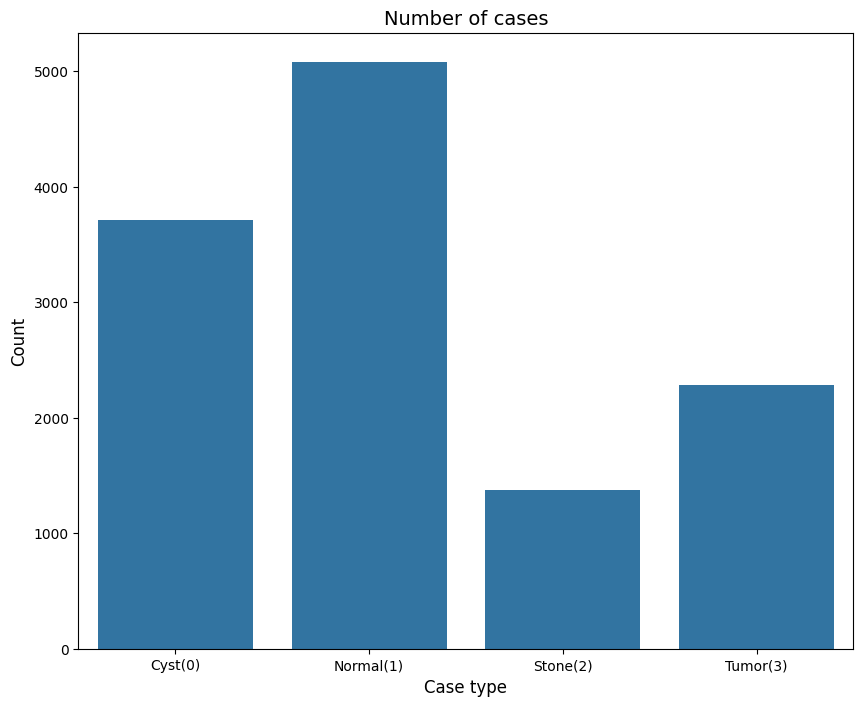

In [15]:
cases_count = train_data['label'].value_counts()
print(cases_count)

# Plot the results 
plt.figure(figsize=(10,8))
sns.barplot(x=cases_count.index, y= cases_count.values)
plt.title('Number of cases', fontsize=14)
plt.xlabel('Case type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(range(len(cases_count.index)), ['Cyst(0)','Normal(1)', 'Stone(2)', 'Tumor(3)'])
plt.show()

In [1]:
import os
os.chdir("../") #change the to the parent dir above the child dir level 
%pwd #to check current dir
#c:\\Users\\Dell\\Downloads\\Kidney_Disease_Classification

'c:\\Users\\Dell\\Downloads\\Kidney_Disease_Classification'

In [25]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class TrainingConfig:
    root_dir: Path
    trained_model_path: Path
    updated_base_model_path: Path
    training_data: Path
    params_epochs: int
    params_batch_size: int
    params_is_augmentation: bool
    params_image_size: list
    params_learning_rate : float

In [27]:
import os
from pathlib import Path
from Kidney_Disease_classification.utils.common import read_yaml, create_directories

class ConfigurationManager:
    def __init__(
        self, 
        config_filepath = Path("config/config.yaml"),
        params_filepath = Path("params.yaml")):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])

    def get_training_config(self) -> TrainingConfig:
        training = self.config.training
        prepare_base_model = self.config.prepare_base_model
        params = self.params
        
        # Path to the unzipped images folder
        training_data = os.path.join(
            self.config.data_ingestion.unzip_dir, 
            "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
        )

        create_directories([Path(training.root_dir)])

        training_config = TrainingConfig(
            root_dir=Path(training.root_dir),
            trained_model_path=Path(training.trained_model_path),
            updated_base_model_path=Path(prepare_base_model.updated_base_model_path),
            training_data=Path(training_data),
            params_epochs=params.EPOCHS,
            params_batch_size=params.BATCH_SIZE,
            params_is_augmentation=params.AUGMENTATION,
            params_image_size=params.IMAGE_SIZE,
            params_learning_rate = params.LEARNING_RATE
        )

        return training_config

In [ ]:
import os
import tensorflow as tf
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

class Training:
    def __init__(self, config: TrainingConfig):
        self.config = config

    def get_base_model(self):
        """Loads the pre-trained base model."""
        self.model = tf.keras.models.load_model(
            self.config.updated_base_model_path
        )

    def _prepare_dataframes(self):
        """Creates a DataFrame of image paths and splits it into Train, Val, and Test."""
        train_dir = Path(self.config.training_data)
        classes = ['Normal', 'Cyst', 'Stone', 'Tumor']
        data = []
        # Read images and assign labels
        for class_name in classes:
            class_dir = train_dir / class_name
            for img_path in class_dir.glob('*.jpg'):
                # flow_from_dataframe requires string labels for categorical classification
                data.append((str(img_path), class_name))

        df = pd.DataFrame(data, columns=['image', 'label'])
        # Shuffle the full dataset
        df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
        train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
        val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])
        return train_df, val_df, test_df

    def train_valid_test_generators(self):
        """Initializes the data generators with resizing, augmentation, and splitting."""
        
        train_df, val_df, test_df = self._prepare_dataframes()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        test_csv_path = Path(self.config.root_dir) / "test_data.csv"
        self.test_df.to_csv(test_csv_path, index=False)
        datagenerator_kwargs = dict(rescale=1./255)
        dataflow_kwargs = dict(
            x_col='image',
            y_col='label',
            target_size=self.config.params_image_size[:-1], 
            batch_size=self.config.params_batch_size,
            class_mode="categorical",
            interpolation="bilinear"
        )

        valid_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagenerator_kwargs)

        self.valid_generator = valid_test_datagen.flow_from_dataframe(
            dataframe=self.val_df,
            shuffle=False, 
            **dataflow_kwargs
        )

        self.test_generator = valid_test_datagen.flow_from_dataframe(
            dataframe=self.test_df,
            shuffle=False, 
            **dataflow_kwargs
        )
        if self.config.params_is_augmentation:
            train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
                rotation_range=40,
                horizontal_flip=True,
                width_shift_range=0.2,
                height_shift_range=0.2,
                shear_range=0.2,
                zoom_range=0.2,
                **datagenerator_kwargs
            )
        else:
            train_datagen = valid_test_datagen

        self.train_generator = train_datagen.flow_from_dataframe(
            dataframe=self.train_df,
            shuffle=True,
            **dataflow_kwargs
        )
    
    @staticmethod
    def save_model(path: Path, model: tf.keras.Model):
        model.save(path)
        
    def train(self):
        self.steps_per_epoch = len(self.train_df) // self.config.params_batch_size
        self.validation_steps = len(self.val_df) // self.config.params_batch_size
        fresh_optimizer = tf.keras.optimizers.SGD(learning_rate=self.config.params_learning_rate) 
        self.model.compile(
            optimizer=fresh_optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        self.model.fit(
            self.train_generator,
            epochs=self.config.params_epochs,
            steps_per_epoch=self.steps_per_epoch,
            validation_steps=self.validation_steps,
            validation_data=self.valid_generator
        )
        self.save_model(
            path=self.config.trained_model_path,
            model=self.model
        )


In [1]:
# STAGE_NAME = "Training Pipeline Stage"
# try:
#     config = ConfigurationManager()
#     training_config = config.get_training_config()
#     training = Training(config=training_config)
#     training.get_base_model()
#     training.train_valid_test_generators() 
#     training.train()
# except Exception as e:
#     raise e

In [1]:
import os
os.chdir("../") #change the to the parent dir above the child dir level 
%pwd #to check current dir
#c:\\Users\\Dell\\Downloads\\Kidney_Disease_Classification

'c:\\Users\\Dell\\Downloads\\Kidney_Disease_Classification'

In [2]:
import tensorflow as tf
model = tf.keras.models.load_model("artifacts/training/trained_model.h5")

In [5]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class EvaluationConfig:
    path_of_model: Path
    training_data: Path
    all_params: dict
    mlflow_uri: str
    params_image_size: list
    params_batch_size: int

In [7]:
import os
from pathlib import Path
from Kidney_Disease_classification.utils.common import read_yaml, create_directories

class ConfigurationManager:
    def __init__(
        self, 
        config_filepath = Path("config/config.yaml"),
        params_filepath = Path("params.yaml")):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_eval_config(self) -> EvaluationConfig:
        eval_config = EvaluationConfig(
            path_of_model=Path("artifacts/training/trained_model.h5"),
            training_data=Path(os.path.join(self.config.data_ingestion.unzip_dir, "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")),
            mlflow_uri="https://dagshub.com/Sai_Tharshith_97/Kidney_Disease_Classification.mlflow",
            all_params=self.params,
            params_image_size=self.params.IMAGE_SIZE,
            params_batch_size=self.params.BATCH_SIZE
        )
        return eval_config

In [ ]:
class Evaluation:
    self.config = config 
    